# Основы глубинного обучения, майнор ИАД

## Домашнее задание 1: полносвязные сети

**ФИО: Новикова Ирина Владимировна ИАД3**

**Факт о себе: люблю чипсы, особенно с огурцом**


## Общая информация

__Дата выдачи:__ 22.09.2025

__Мягкий дедлайн:__ 23:59MSK 12.10.2025

__Жесткий дедлайн:__ 23:59MSK 19.10.2025


## Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).  Если два студента сгенерировали в нейронке одинаковые либо похожие решения, это считается плагиатом и приводит к обнулению обеих работ.

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Итогова оценка считается как

$$
min(part_1, part_2) \cdot 0.6 + max(part_1, part_2) \cdot 0.2 + part_3 \cdot 0.2
$$

где $part_1$, $part_2$ и $part_3$ - оценки за первую, вторую и третью части работы

> Также, за домашнее задание выставляется 0, если не сделано нулевое задание либо нет подробного описания ваших экспериментов в третьей части.

## Оформление

1. Обязательно фиксируйте зерно генератора случайных чисел в экспериментах. При перезапуске кода значения не должны меняться.
2. Вверху файла подпишите фамилию, имя и какой-то занимательный факт о себе.
3. Обратите внимание, что у графиков должны быть подписаны оси, заголовок графика и при необходимости обязательно наличие легенды.

> За отсутствие названий графиков и подписей к осям могут снижаться баллы. Все картинки должны быть самодостаточны и визуально удобны для восприятия, так чтобы не нужно было смотреть ваш код или знать задание, чтобы понять что на них изображено.

Из каждого проведённого эксперимента делайте выводы и фиксируйте их. Эти выводы не должны быть поверхностными и очевидными. Не будьте мудрым королём.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/king.png" width="300">
</center>

**Пример плохого вывода:** Синенькая линия идет вверх, а красная вниз. Черненькая идет вниз, а потом вверх.

<br>

<center>
<img src="https://raw.githubusercontent.com/hse-ds/iad-deep-learning/refs/heads/master/2025/homeworks/bad_lines.png" width="600">
</center>

## О задании

Вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html).

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

import pandas as pd
import numpy as np
import random

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget -O yearpredictionmsd.zip https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip

In [ ]:
df = pd.read_csv('yearpredictionmsd.zip', header=None)
df.head()

Посмотрим на статистики по данным.

In [ ]:
df.describe()

Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

In [ ]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

## Полезные советы:

- Если вы сразу реализуете обучение на GPU, то у вас будет больше времени на эксперименты, так как любые вычисления будут работать быстрее. Google Colab предоставляет несколько GPU-часов (обычно около 8-10) в сутки бесплатно.

- Если вы чего-то не знаете, не стесняйтесь гуглить. В интернете очень много полезной информации, туториалов и советов по глубинному обучению и `pytorch`. Но не забывайте, что за списанный код без ссылки на источник последует наказание.

- Чтобы отладить код, можете обучаться на небольшой части данных или даже на одном батче. Если лосс на обучающей выборке не падает, то что-то точно идет не так.

- Пользуйтесь утилитами, которые вам предоставляет `pytorch` (например, `Dataset` и `Dataloader`). Их специально разработали для упрощения разработки пайплайна обучения.

- Скорее всего, вы захотите отслеживать прогресс обучения. Для создания прогресс-баров есть удобная библиотека `tqdm`.

- Быть может, вы захотите, чтобы графики рисовались прямо во время обучения. Можете воспользоваться функцией [clear_output](http://ipython.org/ipython-doc/dev/api/generated/IPython.display.html#IPython.display.clear_output), чтобы удалять старый график и рисовать новый на его месте.

- При желании вы можете логгировать метрики обучения и свои эксперименты в WandB либо любой другой сервис. Не забудьте приложить к тетрадке ссылку на результаты экспериментов либо скришноты графиков с пояснениями, что проверяющий должен на них увидеть.

- Финальное значение тестовой метрики для удобства проверки выведите в тетрадке.

## Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов)

Мы будем использовать RMSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

Для выполнения данного задания (и всех последующих) предобработайте данные.

1. Зафиксируйте random_seed везде где только возможно. Вам предоставлена функция для этого, однако вы можете дополнить ее своими дополнениями.
2. Обучите `StandertScaler` и предобработайте ваши данные. В следующих заданиях можете использовать другой `scaler` или вообще отказаться от него.


In [ ]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.backends.cudnn.deterministic = True
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def mean_square_error(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)
def root_mean_square_error(y_pred, y_true):
    return np.sqrt(mean_square_error(y_pred, y_true))

In [ ]:
from sklearn.linear_model import Ridge

model = Ridge()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse_for_model = root_mean_square_error(y_test, y_pred)

print(rmse_for_model)

Лучшая константа для RMSE это среднее. Используйте среднее, расчитанное на трэйне в качестве прогноза для теста и посчитайте для такой наивной модели RMSE.

In [ ]:
average_const = y_train.mean()
y_pred = np.array([average_const] * len(y_test))
best_rmse_metric = root_mean_square_error(y_test, y_pred)
print(best_rmse_metric)

Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию. Тестовую выборку мы будем использовать только для того, чтобы измерить итоговую метрику качества модели.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

## Часть I. Обучаем линейную регрессию (максимум 10 баллов)

**Задание 1 (10 баллов):** Обучите в `pytorch` линейную регрессию.

- Создайте модель линейной регрессии, которая будет состоять только из одного `Linear()` слоя.
   
- Напишите цикл обучения вашей линейной регрессии. В нем реализуйте подсчет функции потерь, сделайте шаг градиентного спуска. Запрещено использовать готовые оптимизаторы и loss-функции из библиотеки `pytorch`. Для подсчета градиента воспользуйтесь методом backward.
   
- Запустите обучение на 10 эпохах, после каждой проверяйте значение целевой метрики на тестовой выборке.
   
- Выведите на экран графики метрики и значения функции потерь на тестовой и обучающей выборке.

В данном задании нет цели побить какой-то порог по метрике. Ваша задача &mdash; убедиться в том, что ваш рукописный цикл обучения работает. Для ускорения вычислений и обучения модели можете брать только срез данных, а не весь датасет.

Создадим класс-обертку над данными:

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return (torch.tensor(self.x[idx, :], dtype=torch.float), self.y[idx])

In [ ]:
train_set = MyDataset(X_train, y_train)
test_set = MyDataset(X_val, y_val)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=64, shuffle=True, generator=g, worker_init_fn=seed_worker
)

test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=64, shuffle=False, generator=g, worker_init_fn=seed_worker
)

Создадим нейронную сеть с одним линейным слоем:

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
in_features = X_train.shape[1]
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features).to(device)

Функция для расчета RMSE:

In [ ]:
def mean_square_error(y_pred, y_true):
  return torch.mean((y_pred - y_true) ** 2)
def root_mean_square_error(y_pred, y_true):
  return torch.sqrt(mean_square_error(y_pred, y_true))

Цикл обучения:

In [ ]:
epochs = 10
lr = 1e-3
train_losses = []
test_losses = []

for i in range(epochs):
  train_loss = 0.0
  model.train()

  for features, labels in tqdm(train_loader):
    features = features.to(device)
    labels = labels.to(device)

    y_pred = model(features)
    loss = root_mean_square_error(y_pred, labels)

    model.zero_grad()
    loss.backward()

    with torch.no_grad():
      for w in model.parameters():
        w -= lr * w.grad

    train_loss += loss.item() * features.size(0)

  average_train_loss = train_loss / len(train_loader.dataset)
  train_losses.append(average_train_loss)

  test_loss = 0.0
  model.eval()
  for features, labels in tqdm(test_loader):
    features = features.to(device)
    labels = labels.to(device)

    with torch.no_grad():
      y_pred_test = model(features)
      loss = root_mean_square_error(y_pred_test, labels)

      test_loss += loss.item() * features.size(0)

  average_test_loss = test_loss / len(test_loader.dataset)
  test_losses.append(average_test_loss)

  print(f'Epoch: {i}')
  print(f'loss на train: {average_train_loss}, loss на test: {average_test_loss}')

In [ ]:
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15})

fig, axs = plt.subplots(figsize=(13, 4))
plt.title('Loss для линейной регрессии (нейросеть с одним линейным слоем)')
plt.plot(range(1, len(train_losses) + 1), train_losses, label='train')
plt.plot(range(1, len(test_losses) + 1), test_losses, label='test')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend()
plt.show()

**Ошибка на train и на test падает, поэтому можно сделать вывод, что цикл обучения работает корректно.**

## Часть II. Заводим нейронную сеть (максимум 10 баллов)

Ниже нам предстоит реализовать довольно много различных нейросетей и поставить целую серию экспериментов. Чтобы это всё происходило без боли и страданий, нам нужно держать код в удобном виде.

При решении заданий вы можете придерживаться любой адекватной струкуры кода, но мы советуем воспользоваться сигнатурами функций, которые приведены ниже. При необходимости вы можете добавить в них любые нужные вам аргументы и любой нужный функционал. Более того, хорошей практикой является не делать эти функции слишком громоздкими и выносить разные хитрые штуки в отдельные функции.

Перепишем функцию для расчета RMSE с учетом того, что модель предсказывает классы:

In [ ]:
#посмотрим на целевую переменную
years = np.sort(df.iloc[:, 0].unique())
number_of_years = len(years)
print(f'Количество уникальных значений: {number_of_years}')
print('Уникальные значения:')
print(years)

In [ ]:
#создадим словарь, где ключ - это класс(от 0 до 88), а значение - соответствующий классу год
d_years = dict()
for number in range(number_of_years):
  d_years[number] = int(years[number])

In [ ]:
def rmse(y_pred, y_true, model_type):
  #если мы считаем rmse для классификации, то нужно преобразовать класс обратно в год
  if (model_type == 'c'):
    y_pred_classes = y_pred.argmax(dim=1)
    y_true_classes = y_true.long()

    y_pred = torch.tensor([d_years[int(x)] for x in y_pred_classes], device=device, dtype=torch.float32)
    y_true = torch.tensor([d_years[int(x)] for x in y_true_classes], device=device, dtype=torch.float32)

  return torch.sqrt(((y_pred - y_true)**2).mean())

Остальные функции(функцию для визуализации графика взяла из семинарского ноутбука):

In [ ]:
def plot_losses(train_losses, test_losses, train_rmses, test_rmses, title):
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))
    plt.suptitle(title)
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(test_losses) + 1), test_losses, label='test')
    axs[0].set_ylabel('loss')

    axs[1].plot(range(1, len(train_rmses) + 1), train_rmses, label='train')
    axs[1].plot(range(1, len(test_rmses) + 1), test_rmses, label='test')
    axs[1].set_ylabel('rmse')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    plt.show()

In [ ]:
def training_epoch(model, optimizer, criterion, train_loader, model_type):
    """Одна эпоха обучения
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        model_type - тип модели (классификация или регрессия)
    """
    train_loss, train_rmse = 0.0, 0.0
    model.train()
    for features, labels in tqdm(train_loader):
      features = features.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      y_pred = model(features)
      if (model_type == 'denorm'):
        y_pred = denormalize(y_pred)
        labels = denormalize(labels)
      loss = criterion(y_pred, labels)
      loss.backward()
      optimizer.step()

      train_loss += loss.item() * features.size(0)
      train_rmse += rmse(y_pred, labels, model_type).item() * features.size(0)

    average_train_loss = train_loss / len(train_loader.dataset)
    average_train_rmse = train_rmse / len(train_loader.dataset)
    print(f'loss на train: {average_train_loss}, rmse на train: {average_train_rmse}')
    return average_train_loss, average_train_rmse

@torch.no_grad()
def validation_epoch(model, criterion, val_loader, model_type):
    """Одна эпоха валидации модели
    params:
        model - torch.nn.Module to be fitted
        criterion - loss function from torch.nn
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        model_type - тип модели (классификация или регрессия)
    """
    test_loss, test_rmse = 0.0, 0.0
    model.eval()
    for features, labels in tqdm(val_loader):
      features = features.to(device)
      labels = labels.to(device)

      y_pred = model(features)
      if (model_type == 'denorm'):
        y_pred = denormalize(y_pred)
        labels = denormalize(labels)
      loss = criterion(y_pred, labels)
      test_loss += loss.item() * features.size(0)
      test_rmse += rmse(y_pred, labels, model_type).item() * features.size(0)

    average_test_loss = test_loss / len(val_loader.dataset)
    average_test_rmse = test_rmse / len(val_loader.dataset)
    print(f'loss на val: {average_test_loss}, rmse на val: {average_test_rmse}')
    return average_test_loss, average_test_rmse


@torch.no_grad()
def predict(model, data_loader, model_type=''):
    """ Предсказания модели
    params:
        model - torch.nn.Module to be evaluated on test set
        data_loader - torch.utils.data.Dataloader with test set
    ----------
    returns:
        average_rmse - ошибка модели
    """
    model.eval()
    test_rmse = 0.0

    for features, labels in tqdm(data_loader):
        features = features.to(device)
        labels = labels.to(device)

        y_pred = model(features)
        y_pred_denorm = denormalize(y_pred)
        labels_denorm = denormalize(labels)

        test_rmse += rmse(y_pred_denorm, labels_denorm, model_type).item() * features.size(0)

    average_rmse = test_rmse / len(data_loader.dataset)
    return average_rmse


def train(model, optimizer, criterion, train_loader, val_loader, epochs, model_type):
    """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
        model_type - тип модели (классификация или регрессия)
    """

    train_losses, train_rmses = [], []
    test_losses, test_rmses = [], []

    for i in range(epochs):
      average_train_loss, average_train_rmse = training_epoch(model, optimizer, criterion, train_loader, model_type)
      average_test_loss, average_test_rmse = validation_epoch(model, criterion, val_loader, model_type)
      train_losses.append(average_train_loss)
      train_rmses.append(average_train_rmse)
      test_losses.append(average_test_loss)
      test_rmses.append(average_test_rmse)
      print(f'Epoch: {i}')
    if (model_type == 'c'):
      plot_losses(train_losses, test_losses, train_rmses, test_rmses, 'Loss(кросс-энтропия) и RMSE для классификации(нейросеть с двумя слоями)')
    else:
      plot_losses(train_losses, test_losses, train_rmses, test_rmses, 'Loss(mse) и RMSE для регрессии')

    trained_model = model.state_dict().copy()
    model.load_state_dict(trained_model)

    return train_losses, train_rmses, test_losses, test_rmses, model

**Задание 2 (2 балла)**

Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве метрики качества мы используем RMSE. При его подсчёте вам нужно заменить предсказанный нейросеткой класс на конкретный год выпуска песни и использовать его как прогноз.

In [ ]:
years = np.sort(df.iloc[:, 0].unique())
number_of_years = len(years)
print(f'Количество уникальных значений: {number_of_years}')
print('Уникальные значения:')
print(years)

Можно заметить, что данные содержат все года с 1922 по 2011, кроме 1923.

Закодируем каждый год, как отдельный класс, значениями от 0 до 88, таким образом, что:

1922 - 0 класс

1924 - 1 класс

2011 - 88 класс

In [ ]:
d = dict()
for number in range(number_of_years):
  d[int(years[number])] = number

In [ ]:
year_class = []
years = np.array(df.iloc[:, 0])
for year in years:
  year_class.append(d[year])
print(year_class[:10])

In [ ]:
idx = max(map(int, df.columns)) + 1
df[idx] = year_class
df.head(3)

Разобьем данные на обучение и тест:

In [ ]:
#удаляем столбец с годом выпуска песен
new_df = df.drop(columns=df.columns[0])
new_df.head(5)

In [ ]:
#отделяем целевую переменную
X = new_df.iloc[:, :90].values
y = new_df.iloc[:, 90].values

In [ ]:
#делим на обучение и тест
train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

Выделим валидационную часть:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

Обернем валидационную и обучающую выборку в класс MyDataset, чтобы было удобнее работать с данными:

In [ ]:
train_set = MyDataset(X_train, y_train)
val_set = MyDataset(X_val, y_val)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=64, shuffle=True, generator=g, worker_init_fn=seed_worker
)

val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, generator=g, worker_init_fn=seed_worker
)

Напишем модель нейросети с двумя слоями и активацией ReLU между ними:

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, num_classes, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
NUM_CLASSES = number_of_years
HIDDEN_SIZE = 128
NUM_EPOCH = 4
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], num_classes=NUM_CLASSES, hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'c')

**Задание 3 (1 балл).** Прокомментируйте ваши наблюдения. Удалось ли побить бейзлайн? Как вы думаете, хорошая ли идея учить классификатор для этой задачи? Почему?

**Ответ:** rmse для бейзлайна(ridge-регрессия) равна 9.47. В случае с классификацией rmse после 10 эпох равна примерно 13.82. Бейзлайн побить не удалось.
Мне кажется, что применять классификатор для такой задачи, не очень хорошая идея, потому что целевая переменная(год выпуска песни) по сути непрерывная величина. Применяя классификацию в таком случае, мы получаем слишком много классов и как будто логичнее решать задачу, как регрессию. В итоге, модель получилась не такой эффективной, как бейзлайн.

**Задание 4 (2 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=1),
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y.reshape(-1, 1), dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [ ]:
new_df2 = df.drop(columns=df.columns[91])
new_df2.head()

In [ ]:
X = new_df2.iloc[:, 1:].values
y = new_df2.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])

X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]

X_train.shape, X_test.shape

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

In [ ]:
train_set = MyDataset(X_train, y_train)
val_set = MyDataset(X_val, y_val)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=64, shuffle=True, generator=g, worker_init_fn=seed_worker
)

val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, generator=g, worker_init_fn=seed_worker
)

In [ ]:
NUM_CLASSES = number_of_years
HIDDEN_SIZE = 128
NUM_EPOCH = 4
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'r')

**Задание 5 (1 балл).** Получилось ли у вас стабилизировать обучение? Помогли ли меньшие значения `lr`? Стало ли лучше от замены классификации на регрессию? Как вы думаете, почему так происходит? В качестве подсказки можете посмотреть на распределение целевой переменной и магнитуду значений признаков.

**Ответ:** обучение стабилизировать не получилось. Изменение lr также не помогло, модель не обучается, ошибки на train и на test равны nan. Если посмотреть на распределение целевой переменной, то можно увидеть, что оно сильно скошено влево и что большинство песен в датасете были выпущены в 2000-е года, тогда как с 1922 по 1980 их было выпущено в разы меньше. Кроме того, масштабы признаков отличаются, есть признаки, для которых среднее значение = -1.793236(8 признак), а есть те, для которых среднее значение = 2439.359375	(14 признак). Неоднородность целевой переменной и разные масштабы признаков приводят к тому, что градиенты становятся нестабильными и пропускают локальные минимумы, из-за чего обучение расходится.


In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df.describe()

**Задание 6 (1 балл).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [ ]:
max_value = max(y_train)
min_value = min(y_train)
print(f'Максимальное значение: {max_value}')
print(f'Минимальное значение: {min_value}')

In [ ]:
def normalize(sample):
    """
    Min-max normalization to convert sample to [0, 1] range
    """
    normalized_sample = (sample - min_value) / (max_value - min_value)
    return normalized_sample

def denormalize(sample):
    """
    Denormalize sample from [0, 1] to initial range
    """
    denormalized_sample = min_value + sample * (max_value - min_value)
    return denormalized_sample

**Задание 7 (1 балл)** Теперь повторите эксперимент из **задания 4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений.

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
y_train_norm = normalize(y_train)
y_val_norm = normalize(y_val)

In [ ]:
train_set = MyDataset(X_train, y_train_norm)
val_set = MyDataset(X_val, y_val_norm)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=64, shuffle=True, generator=g, worker_init_fn=seed_worker
)

val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, generator=g, worker_init_fn=seed_worker
)

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-4

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

**Задание 8 (2 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
train_set = MyDataset(X_train_scaled, y_train_norm)
val_set = MyDataset(X_val_scaled, y_val_norm)

In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=64, shuffle=True, generator=g, worker_init_fn=seed_worker
)

val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=64, shuffle=False, generator=g, worker_init_fn=seed_worker
)

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

В результате получилась модель с rmse равной примерно 9.0 на test, тогда как Ridge-регрессия имеет rmse равное 9.47. Наша модель достигла качества, сравнимого с бейзлайном.

Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть III. Улучшаем нейронную сеть (максимум 10 баллов)

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества.

**Задание 9 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

Применим в качестве оптимизатора SGD+momentum:

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-5

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Использование momentum привело к тому, что модель стала работать лучше( ранее rmse было приблизительно равно 9, сейчас оно около 8.8). Импульс позволяет учитывать предыдущие изменения весов при обновлении. В результате, в областях, где линии уровня вытянутые, градиент работает быстрее. Благодаря импульсу сглаживаются сильные колебания градиента и его траектория становится более стабильной.

Применим в качестве оптимизатора Adam:

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Оптимизатор Adam сочетает в себе инерцию и адаптивность. Под адаптивностью понимается способность задать каждому параметру свою скорость обучения. За счет этого для параметров, которые часто обновляются, мы делаем большие шаги в самом начале, а для тех, что редко обновляются, - маленькие. В нашем случае оптимизатор улучшил модель, теперь rmse на тесте = 8.75, поэтому далее будем использовать его.

**Задание 10 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Делаем нейросеть более широкой:

In [ ]:
HIDDEN_SIZE = 128 * 2
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Делаем нейросеть более глубокой:

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. Увеличение количества нейронов в скрытом слое в два раза привело к тому, что ошибка на тесте немного увеличилась, в то время как на обучении ошибка упала. Это говорит о том, что сеть переобучилась. Слишком большое количество нейронов может привести к тому, что обучающих данных не хватит, чтобы всех их обучить, поэтому не всегда увеличение кол-ва нейронов улучшает качество сети.

2. Добавление еще одного скрытого слоя также привело к переобучению, но к более сильному. У нас не такой большой датасет и по всей видимости он не содержит сложных паттернов, для распознавания которых нам потребуется много слоев. Поэтому одного скрытого слоя вполне достаточно. Либо же стоит добавить регуляризацию, чтобы избежать переобучения.

**Задание 11 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Добавили слои дропаута:

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Добавили batch-нормализацию:

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR = 1e-3

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features = X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, betas=(0.9, 0.999))
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

1. Добавление слоев дропаута позволяет временно исключить некоторые нейроны на каждом шаге обучения. Параметр p = 0.2 говорит о том, что каждый нейрон может быть исключен из сети с вероятностью 0.2. Это позволяет избежать ситуации, когда нейронная сеть зависит от какого-то конкретного узла, и снижает возможность переобучения. В нашем случае добавление дропаута действительно снизило переобучение и ошибка на тестовых данных уменьшилась(8.62).

2. Добавление batch-нормализации после каждого слоя также позволило снизить переобучение. Данный подход нормализует выход каждого слоя, из-за чего нейросеть становится более стабильной, так как масштаб входных данных теперь не влияет на выходы. В результате на тесте ошибка rmse = 8.58.

**Задание 12 (1 балл).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению RMSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения). Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости RMSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

In [ ]:
HIDDEN_SIZE = 128
NUM_EPOCH = 10
LR_variants = [1e-2, 1e-3, 1e-4]
wd_variants = [0, 1e-2, 1e-3, 1e-4, 1e-5]

results = dict()
for lr in LR_variants:
    results[lr] = dict()
    for wd in wd_variants:
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        model = NeuralNet(in_features=X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        criterion = nn.MSELoss()

        train_losses, train_rmses, val_losses, val_rmses, model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

        results[lr][wd] = {'train_rmses': train_rmses, 'val_rmses': val_rmses}

        print(f"Train_rmse = {train_rmses[-1]}, val_rmse = {val_rmses[-1]} for LR = {lr} and wd = {wd}")

In [ ]:
fig, axes = plt.subplots(nrows=len(LR_variants), ncols=len(wd_variants), figsize=(6*len(wd_variants), 4*len(LR_variants)))

for i, lr in enumerate(LR_variants):
    for j, wd in enumerate(wd_variants):
        ax = axes[i, j]
        train_rmses = results[lr][wd]['train_rmses']
        val_rmses = results[lr][wd]['val_rmses']
        epochs = range(1, len(train_rmses) + 1)

        ax.plot(epochs, train_rmses, label='Train RMSE', marker='o')
        ax.plot(epochs, val_rmses, label='Val RMSE',  marker='o')
        ax.set_title(f'LR={lr}, WD={wd}\nFinal: Train={train_rmses[-1]:.1f}, Val={val_rmses[-1]:.2f}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('RMSE')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Опишите результаты экспериментов (без их описания за работу ставится ноль баллов)

__Ваше подробное описание:__

**1. Скорость обучения**

Низкая скорость обучения (LR = 1e-4) приводит к тому, что градиент застревает в локальных минимумах. Ошибка на валидации составляет 8.7. Это высокая ошибка по сравнению с другими результатами. Но по графикам видно, что переобучение практически отсутствует(3 строка), что хорошо.

Средняя скорость обучения (LR = 1e-3) уменьшает ошибку, на валидационных данных она приблизительно равна 8.6(2 строка) и это лучший результат. Однако переобучение увеличивается.

Сильно высокая скорость обучения (LR = 1e-2) повышает ошибку и приводит к переобучению, траектория ошибки сильнее колеблется.

**2. Weight Decay**

Weight Decay позволяет штрафовать модель.

В целом если посмотреть на все графики слева на право, то можно увидеть, что по мере уменьшения коэффицента wd лучше работает нейросеть, ошибка уменьшается.

Большой коэф wd приводит к ухудшению модели. Если смотреть на первые два графика (1 строка), то можно увидеть, что до добавления регуляризации ошибка была меньше. После добавления она сильно возрасла. Это значит, что мы слишком штрафуем модель.

С точки зрения качества, лучше брать небольшой wd, он позволит штрафовать большие веса, но при этом добиться наименьшей ошибки.



Худшим вариантом является LR = 0.01 и wd = 0.01, так как ошибка на на обучающих и валидационных данных в этом случае самая высокая и приблизительно равно 8.9. Присутствует переобучение, особенно первые 5 эпох.

Лучшим вариантом является LR = 0.001 и wd = 1e-5. При таких гиперпараметрах rmse на train равна 8.3, на val - 8.57.


> Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.




**Задание 13 (6 баллов).**

Думаю направление размышлений вы поняли. Постарайтесь с помощью своих экспериментов выбить максимально возможное значение RMSE на тестовой выборке. Соотношение между полученным значением метрики на тестовой выборке и баллами за задание следующее:

- $\text{RMSE} \le 8.90 $ &mdash; 2 балла
- $\text{RMSE} \le 8.80 $ &mdash; 4 балла
- $\text{RMSE} \le 8.75 $ &mdash; 6 баллов

**Различные трюки, которые можно попробовать:**

1. Попробуйте делать во время обучения раннюю остановку обучения и сохранять модель в тот момент, когда качество на валидации начало ухудшаься, то есть модель начала переобучаться
2. Попробуйте усложнить архитектуру нейросет
    - Больше/меньше нейронов
    - Больше/меньше слоёв
    - Другие функции активации (tanh, relu, leaky relu, elu etc)
    - Регуляризация (dropout, l1,l2)
3. Попробуйте другие оптимизаторы, а также смену скорости обучения по расписанию.

И это далеко не полный список. Обратите внимание, что делать grid_search для больших сеток это довольно времязатратное занятие... Попробовать несколько значений, как мы делали в заданиях выше, адекватно, но делать какой-то огромный перебор будет самоубийством.

Логгируйте свои эксперименты. За один прогон пробуйте одно изменение. Иначе будет непонятно какие именно изменения улучшили качество, а какие ухудшили.

**Для начала применим модель с подобранными гиперпараметрами и посмотрим, какая ошибка будет на тесте:**

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

In [ ]:
y_test_norm = normalize(y_test)
X_test_scaled = scaler.transform(X_test)

In [ ]:
test_set = MyDataset(X_test_scaled, y_test_norm)

In [ ]:
test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=64, shuffle=True
)

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

In [ ]:
test_rmse = predict(trained_model, test_loader)
test_rmse

На данный момент ошибка на тесте равна 8.62

Добавим раннюю остановку обучения:

In [ ]:
def train(model, optimizer, criterion, train_loader, val_loader, epochs, model_type, p=3):
  """ Обучение модели
    params:
        model - torch.nn.Module to be fitted
        optimizer - model optimizer
        criterion - loss function from torch.nn
        train_loader - torch.utils.data.Dataloader with train set
        val_loader - torch.utils.data.Dataloader with test set
                      (if you wish to validate during training)
        epochs - number of training epochs
        model_type - тип модели (классификация или регрессия)
        p - допустимое количество эпох без улучшения
  """
  train_losses, train_rmses = [], []
  test_losses, test_rmses = [], []

  best_loss = float('inf')
  count_no_improve = 0
  best_model_state_dict = None

  for i in range(epochs):
      average_train_loss, average_train_rmse = training_epoch(model, optimizer, criterion, train_loader, model_type)
      average_test_loss, average_test_rmse = validation_epoch(model, criterion, val_loader, model_type)
      train_losses.append(average_train_loss)
      train_rmses.append(average_train_rmse)
      test_losses.append(average_test_loss)
      test_rmses.append(average_test_rmse)

      if average_test_loss < best_loss:
          best_loss = average_test_loss
          best_model_state_dict = model.state_dict().copy()
          count_no_improve = 0
      else:
          count_no_improve += 1
          if count_no_improve >= p:
              print(f"Ранняя остановка")
              break

      print(f'Epoch: {i + 1}')
  if (model_type == 'c'):
    plot_losses(train_losses, test_losses, train_rmses, test_rmses, 'Loss(кросс-энтропия) и RMSE для классификации(нейросеть с двумя слоями)')
  else:
    plot_losses(train_losses, test_losses, train_rmses, test_rmses, 'Loss(mse) и RMSE для регрессии')

  if best_model_state_dict is not None:
      model.load_state_dict(best_model_state_dict)

  return train_losses, train_rmses, test_losses, test_rmses, model

**Эксперимент №1. Попробуем изменить функцию активации на tanh:**

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.Tanh(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.Tanh(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

In [ ]:
test_rmse = predict(trained_model, test_loader)
test_rmse

**Вывод:** стало сильно хуже(ошибка увеличилась на 0.2), что ожидаемо, так как гиперболический тангенс имеет выходной интервал от -1 до 1, а batch-нормализация предполагает, что у нас нормальное распределение. Также сигмоида в конце сжимает выходы в диапазон [0, 1] и получается несоответствие между внутренними слоями и последним слоем.

Ну ради интереса стоило попробовать.

**Эксперимент №2. Поменяем оптимизатор на Adagrad c lr = 0.01:**

In [ ]:
from torch import nn
import torch.nn.functional as F
class NeuralNet(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=hidden_size),
            nn.ReLU(),
            nn.BatchNorm1d(num_features=hidden_size),
            nn.Linear(in_features=hidden_size, out_features=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=X_train.shape[1], hidden_size=HIDDEN_SIZE).to(device)
optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

In [ ]:
test_rmse = predict(trained_model, test_loader)
test_rmse

**Вывод:** в отличае от Adam, adaGrad не включает в себя инерцию, только адаптивность. Под адаптивностью понимается способность задать каждому параметру свою скорость обучения. За счет этого для параметров, которые часто обновляются, мы делаем большие шаги в самом начале, а для тех, что редко обновляются, - маленькие. Применение adaGrad в нашем случае не улучшило модель, но в целом она получилась практически такой же, как и первоначальная(разница 0.02). Так может произойти, если все признаки распределены равномерно и нет разреженных признаков.

**Эксперимент №3. Попробуем изменить количество скрытых нейронов в первоначальной(пока что лучшей) модели:**

In [ ]:
hidden_sizes = [16, 32, 64, 128, 256]
NUM_EPOCH = 10

results = dict()
for hs in hidden_sizes:
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model = NeuralNet(in_features=X_train.shape[1], hidden_size=hs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    criterion = nn.MSELoss()

    train_losses, train_rmses, val_losses, val_rmses, model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

    results[hs] = {'train_rmses': train_rmses, 'val_rmses': val_rmses}

    print(f"Train_rmse = {train_rmses[-1]}, val_rmse = {val_rmses[-1]} for LR = {lr} and wd = {wd}")

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(hidden_sizes), figsize=(6*len(hidden_sizes), 6))

for i, hs in enumerate(hidden_sizes):
    train_rmses = results[hs]['train_rmses']
    val_rmses = results[hs]['val_rmses']
    epochs = range(1, len(train_rmses) + 1)

    axes[i].plot(epochs, train_rmses, label='Train RMSE', marker='o')
    axes[i].plot(epochs, val_rmses, label='Val RMSE',  marker='o')
    axes[i].set_title(f'Hidden Size={hs}\nResult: Train={train_rmses[-1]:.1f}, Val={val_rmses[-1]:.2f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('RMSE')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

По метрике rmse лучшей получилась модель с 256 нейронами, хотя она имеет сильное переобучение. Это мы заметили и ранее(задание 10). Однако сейчас переобучение чуть меньше, так как используем weight decay.

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = NeuralNet(in_features=X_train.shape[1], hidden_size=256).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.MSELoss()

In [ ]:
train_losses, train_rmses, val_losses, val_rmses, trained_model = train(model, optimizer, criterion, train_loader, val_loader, NUM_EPOCH, 'denorm')

In [ ]:
test_rmse = predict(trained_model, test_loader)
test_rmse

**Вывод:** модель с 256 нейронами получилась хорошей, однако все еще хуже, чем первоначальная. Значит, увеличение числа нейронов все-таки слишком сильно усложняет модель.

Таким образом, лучшей моделью осталась первоначальная модель с rmse = 8.62 на тесте.

## Бонус (0.1 балла)

Прикрепите фотографию того, как вы начали этот сентябрь. Какую самую классную эмоцию вы испытали за прошедший месяц?

Сентябрь я начала хорошо, много гуляла. На набережной было очень красиво, а когда деревья пожелтели вообще невероятно стало. Только недавно наушники себе купила беспроводные и осознала, как круто под музыку гулять. Советую :).


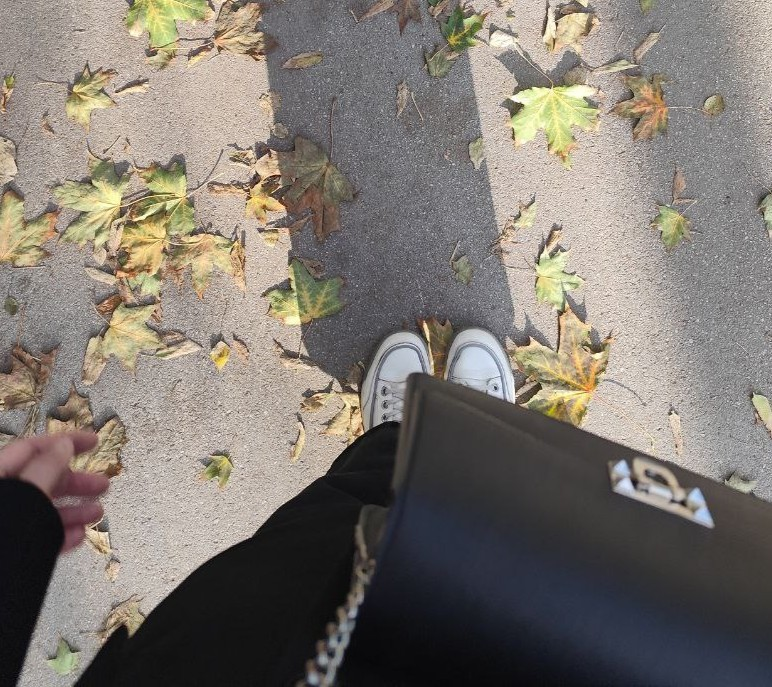

Потом наступил октябрь, стало холодно, сыро и грустно.
На данный момент эмоция:

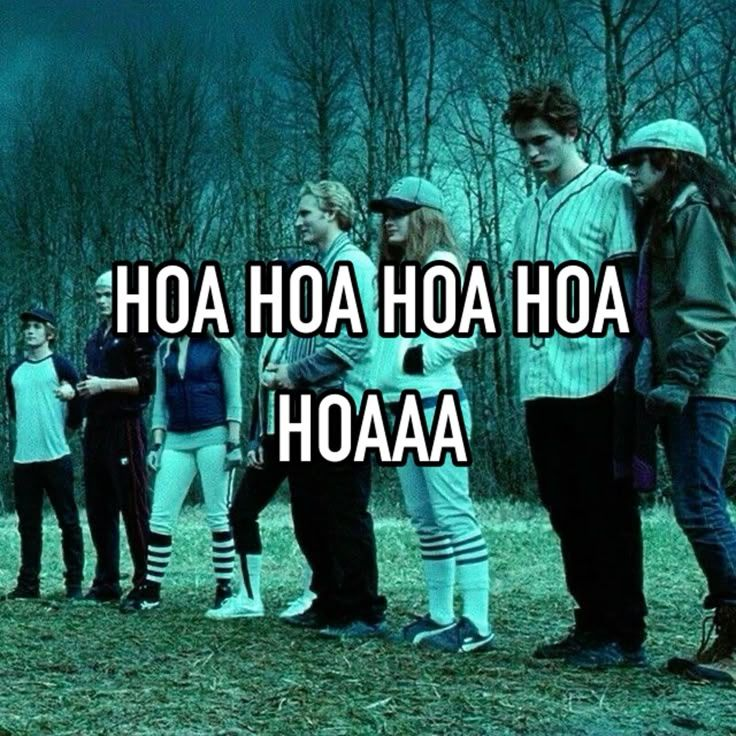